# ViT v5 — TorchXRayVision DenseNet121 + 5-fold CV (target: test AUROC > 0.80)

**Why this should finally cross 0.80**

The v2/v3/v4 ceiling came from two problems:

1. **ImageNet-pretrained ViT isn't tuned for CXR.** Pneumonia opacities look nothing like cats or cars.
2. **Ranking ensembles by a 241-sample val set is noisy** — val AUROC 0.77 and val AUROC 0.75 are statistically indistinguishable, so v4's stacker overfit val and fell back on test.

v5 attacks both:

- **Backbone**: `torchxrayvision` DenseNet121 (`densenet121-res224-all`), pretrained on ~800 k public CXR images (NIH ChestX-ray14, CheXpert, MIMIC-CXR, RSNA Pneumonia, PadChest, OpenI, Google Health, PC-XR). It already has a "Pneumonia" output head and its 1024-d features are tuned for lung pathology. We use it as a (mostly) frozen feature extractor plus a multimodal fusion head.
- **Validation**: **Stratified 5-fold CV on train+val**, test stays held out. For each fold we train a fresh model on 4 folds and predict on the held-out 5th. Stacking those **out-of-fold** predictions with EHR features gives an unbiased stacker — it never trains on the same sample it's later asked to predict.
- **Extra signal**: XRV's own `Pneumonia` probability is added as a stacker feature — free calibrated prior.

**Cost**: ~15–20 min on M5 Pro MPS. Downloads ~100 MB of XRV weights on first run.


## 1. Install & imports

In [ ]:
# Install torchxrayvision and its image deps (first run only — comment out afterwards)
# !pip install -q torchxrayvision scikit-image

In [2]:
import os, random, warnings, copy, time
from pathlib import Path

os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

import torchxrayvision as xrv

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'torch={torch.__version__}   xrv={xrv.__version__}   device={DEVICE}')

torch=2.11.0   xrv=1.4.0   device=mps


## 2. Data, same split as v2/v3 (test held out)

We keep the same test set (random_state=42). The **5-fold CV will run on train+val combined** — that gives each fold ~1089 training / ~272 validation samples, up from the 1120 / 241 we had before, so each fold's val AUROC is a bit less noisy.

In [3]:
# ---- 2.1 paths ----
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'code' else Path.cwd()
DATA_DIR     = PROJECT_ROOT / 'data'
IMG_ROOT     = DATA_DIR / 'files'
COHORT_CSV   = DATA_DIR / 'mimic_ed_cxr_pneumonia_multimodal_cohort.csv'
RESULTS_DIR  = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

for p in (DATA_DIR, IMG_ROOT, COHORT_CSV, RESULTS_DIR):
    assert p.exists(), f'missing: {p}'
print('paths OK')

paths OK


In [4]:
# ---- 2.2 cohort + the same 70/15/15 split as v2/v3 ----
df = pd.read_csv(COHORT_CSV)
LABEL_COL = 'Pneumonia'
df = df.dropna(subset=[LABEL_COL]).reset_index(drop=True)
df[LABEL_COL] = df[LABEL_COL].astype(int)

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df[LABEL_COL], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df[LABEL_COL], random_state=SEED)

# Combine train + val for 5-fold CV; test stays held out
train_val_df = pd.concat([train_df, val_df], ignore_index=True).reset_index(drop=True)
test_df      = test_df.reset_index(drop=True)

y_tv   = train_val_df[LABEL_COL].values.astype(np.float32)
y_test = test_df[LABEL_COL].values.astype(np.float32)

print(f'train+val pool: {len(train_val_df)}  (pos rate {y_tv.mean():.3f})')
print(f'test (held out): {len(test_df)}  (pos rate {y_test.mean():.3f})')

train+val pool: 1360  (pos rate 0.328)
test (held out): 241  (pos rate 0.328)


In [5]:
# ---- 2.3 EHR columns and per-fold preprocessing helpers ----
NUMERIC_COLS = ['age', 'triage_temperature', 'triage_heartrate', 'triage_resprate',
                'triage_o2sat', 'triage_sbp', 'triage_dbp', 'score_CCI']
BINARY_COLS  = ['gender', 'triage_acuity', 'chiefcom_shortness_of_breath',
                'chiefcom_cough', 'chiefcom_fever_chills', 'cci_Pulmonary', 'cci_CHF']
TABULAR_COLS = NUMERIC_COLS + BINARY_COLS
TABULAR_DIM  = len(TABULAR_COLS)

def fit_ehr_preprocessors(tr_df):
    num_imp = SimpleImputer(strategy='median')
    sc      = StandardScaler()
    bin_imp = SimpleImputer(strategy='most_frequent')
    X_num = sc.fit_transform(num_imp.fit_transform(tr_df[NUMERIC_COLS]))
    X_bin = bin_imp.fit_transform(tr_df[BINARY_COLS])
    return (num_imp, sc, bin_imp), np.concatenate([X_num, X_bin], axis=1).astype(np.float32)

def apply_ehr(preps, d):
    num_imp, sc, bin_imp = preps
    X_num = sc.transform(num_imp.transform(d[NUMERIC_COLS]))
    X_bin = bin_imp.transform(d[BINARY_COLS])
    return np.concatenate([X_num, X_bin], axis=1).astype(np.float32)

# Also fit once on the full train+val for the stacker features later
GLOBAL_PREP, X_TAB_TV_GLOBAL = fit_ehr_preprocessors(train_val_df)
X_TAB_TEST_GLOBAL            = apply_ehr(GLOBAL_PREP, test_df)
print(f'tabular dim = {TABULAR_DIM}')

tabular dim = 15


## 3. TorchXRayVision model + Dataset

- Input: 1-channel grayscale, 224×224, range [-1024, 1024] (XRV convention)
- Feature output: 1024-d from `features2(x)` (after global avg-pool, before classifier)
- XRV's native Pneumonia probability: `sigmoid(classifier(features2(x)))[:, pneumonia_idx]` — we keep this as an extra prior for the stacker.

The backbone is downloaded once (~100 MB) and cached; subsequent runs load from disk.

In [6]:
# ---- 3.1 XRV DenseNet121 loader + feature extractor wrapper ----
XRV_WEIGHTS = 'densenet121-res224-all'

# Pre-download weights once (smoke test)
_tmp = xrv.models.DenseNet(weights=XRV_WEIGHTS)
PATHOLOGIES   = _tmp.pathologies
PNEUMONIA_IDX = PATHOLOGIES.index('Pneumonia')
print(f'XRV pathologies ({len(PATHOLOGIES)}):', PATHOLOGIES)
print(f'Pneumonia index: {PNEUMONIA_IDX}')
del _tmp


class XRVMultimodal(nn.Module):
    """
    DenseNet121 (XRV) features (1024-d) ⊕ TabularMLP (64-d) → fusion head → 1 logit.
    The XRV classifier is kept (frozen) so we can also emit the native Pneumonia prob as a side-channel.
    """
    def __init__(self, tab_in_dim, xrv_weights=XRV_WEIGHTS,
                 tab_out_dim=64, head_hidden=128, dropout=0.3):
        super().__init__()
        self.xrv   = xrv.models.DenseNet(weights=xrv_weights)
        self.feat_dim = 1024
        self.mlp = nn.Sequential(
            nn.Linear(tab_in_dim, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, tab_out_dim), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(self.feat_dim + tab_out_dim, head_hidden), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(head_hidden, 1),
        )

    def extract_img_feat(self, img):
        # XRV's features2 = conv stack -> relu -> global avg pool -> flatten
        return self.xrv.features2(img)          # (B, 1024)

    def xrv_pneumonia_prob(self, img):
        """Raw sigmoid of XRV's own Pneumonia classifier (used as a stacker feature)."""
        with torch.no_grad():
            feats = self.xrv.features2(img)
            logits = self.xrv.classifier(feats)  # (B, 18) — skip op_threshs calibration
            return torch.sigmoid(logits[:, PNEUMONIA_IDX])

    def forward(self, img, tab):
        f_img = self.extract_img_feat(img)
        f_tab = self.mlp(tab)
        return self.head(torch.cat([f_img, f_tab], dim=1)).squeeze(-1)


def freeze_xrv_backbone(model):
    for p in model.xrv.parameters():
        p.requires_grad = False

def unfreeze_xrv_backbone(model):
    for p in model.xrv.parameters():
        p.requires_grad = True

print('XRVMultimodal class ready')

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /Users/yj/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]
XRV pathologies (18): ['Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia', 'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia', 'Lung Lesion', 'Fracture', 'Lung Opacity', 'Enlarged Cardiomediastinum']
Pneumonia index: 8
XRVMultimodal class ready


In [7]:
# ---- 3.2 XRV transforms + Dataset ----
# XRV expects 1-channel grayscale with values in [-1024, 1024].

class XRVTransform:
    def __init__(self, img_size=224, augment=False):
        self.img_size = img_size
        self.augment  = augment

    def __call__(self, pil_img):
        gray = pil_img.convert('L')
        if self.augment:
            up = int(self.img_size * 1.15)
            gray = gray.resize((up, up), Image.BILINEAR)
            x0 = np.random.randint(0, up - self.img_size + 1)
            y0 = np.random.randint(0, up - self.img_size + 1)
            gray = gray.crop((x0, y0, x0 + self.img_size, y0 + self.img_size))
            if np.random.rand() < 0.5:
                gray = gray.transpose(Image.FLIP_LEFT_RIGHT)
            # small rotation (±10°) — helps generalise to slight patient tilt
            angle = np.random.uniform(-10, 10)
            gray = gray.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
        else:
            gray = gray.resize((self.img_size, self.img_size), Image.BILINEAR)
        arr = np.array(gray, dtype=np.float32)
        arr = (arr / 255.0) * 2048.0 - 1024.0      # XRV range
        return torch.from_numpy(arr[None, :, :])   # (1, H, W)


def build_image_path(row):
    sid = int(row['subject_id']); sty = int(row['study_id']); did = row['dicom_id']
    return IMG_ROOT / f'p{str(sid)[:2]}' / f'p{sid}' / f's{sty}' / f'{did}.jpg'


class XRVDataset(Dataset):
    def __init__(self, dataframe, tabular_np, labels_np, transform):
        assert len(dataframe) == len(tabular_np) == len(labels_np)
        self.df = dataframe.reset_index(drop=True)
        self.tab = torch.from_numpy(tabular_np)
        self.y = torch.from_numpy(labels_np)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(build_image_path(self.df.iloc[idx])).convert('RGB')
        return self.transform(img), self.tab[idx], self.y[idx]


# Quick smoke test
_tf = XRVTransform(augment=False)
_sample = Image.open(build_image_path(train_val_df.iloc[0])).convert('RGB')
_t = _tf(_sample)
print(f'XRV input shape: {tuple(_t.shape)}   range [{_t.min():.1f}, {_t.max():.1f}]   dtype={_t.dtype}')

XRV input shape: (1, 224, 224)   range [-1024.0, 1024.0]   dtype=torch.float32


## 4. 5-fold stratified CV

For each fold:

1. Fit EHR preprocessors on the 4 training folds only
2. Build a fresh `XRVMultimodal` model (XRV weights are the same starting point, but the fusion head is re-initialized, so folds diverge)
3. **Warmup**: freeze XRV, train fusion head for 3 epochs
4. **Fine-tune**: unfreeze XRV's last dense block, train 5 more epochs with very low backbone LR
5. Keep best-by-val-AUROC checkpoint for this fold
6. Predict on this fold's held-out val (→ OOF) and on the test set
7. Also cache XRV's native Pneumonia probability on val and test (for the stacker)

Final test prediction for this backbone is the average of the 5 folds' test probabilities — a built-in ensemble.

In [8]:
# ---- 4.1 Training primitives ----

def run_epoch_xrv(model, loader, loss_fn, optimizer=None, device=DEVICE, desc=''):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_n = 0.0, 0
    probs, labels = [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for img, tab, y in tqdm(loader, desc=desc, leave=False):
            img = img.to(device, non_blocking=True)
            tab = tab.to(device, non_blocking=True)
            y   = y.to(device, non_blocking=True)
            logit = model(img, tab)
            loss  = loss_fn(logit, y)
            if is_train:
                optimizer.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            bs = y.size(0)
            total_loss += loss.item() * bs; total_n += bs
            probs.append(torch.sigmoid(logit).detach().cpu().numpy())
            labels.append(y.detach().cpu().numpy())
    return total_loss / max(total_n, 1), np.concatenate(probs), np.concatenate(labels)


@torch.no_grad()
def predict_xrv(model, loader, device=DEVICE, desc='predict'):
    """Run inference + also collect XRV native pneumonia prob."""
    model.eval()
    fusion_probs, xrv_pneu_probs, labels = [], [], []
    for img, tab, y in tqdm(loader, desc=desc, leave=False):
        img = img.to(device, non_blocking=True)
        tab = tab.to(device, non_blocking=True)
        fp = torch.sigmoid(model(img, tab)).cpu().numpy()
        xp = model.xrv_pneumonia_prob(img).cpu().numpy()
        fusion_probs.append(fp); xrv_pneu_probs.append(xp); labels.append(y.numpy())
    return (np.concatenate(fusion_probs),
            np.concatenate(xrv_pneu_probs),
            np.concatenate(labels).astype(int))


def unfreeze_last_denseblock(model):
    """Unfreeze only `denseblock4` + its norm/relu, keep earlier blocks frozen."""
    target_names = ('denseblock4', 'norm5')
    for name, p in model.xrv.named_parameters():
        if any(t in name for t in target_names):
            p.requires_grad = True
    trainable = sum(p.numel() for p in model.xrv.parameters() if p.requires_grad) / 1e6
    return trainable


def build_optimizer(model, lr_bb, lr_hd, wd=5e-2):
    bb = [p for p in model.xrv.parameters() if p.requires_grad]
    hd = list(model.mlp.parameters()) + list(model.head.parameters())
    groups = []
    if bb:
        groups.append({'params': bb, 'lr': lr_bb, 'weight_decay': wd})
    groups.append({'params': hd, 'lr': lr_hd, 'weight_decay': wd})
    return torch.optim.AdamW(groups)


print('training primitives ready')

training primitives ready


In [9]:
# ---- 4.2 Run the 5-fold CV ----
N_FOLDS        = 5
BATCH_SIZE     = 32
WARMUP_EPOCHS  = 3
FINETUNE_EPOCHS= 5
LR_HEAD        = 1e-3
LR_BACKBONE    = 1e-5
NUM_WORKERS    = 0

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_fusion   = np.zeros(len(train_val_df), dtype=np.float32)
oof_xrv_pneu = np.zeros(len(train_val_df), dtype=np.float32)
test_fusion  = np.zeros((N_FOLDS, len(test_df)), dtype=np.float32)
test_xrv_pneu= np.zeros((N_FOLDS, len(test_df)), dtype=np.float32)
per_fold_val_auroc = []

t_global = time.time()

for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(train_val_df, y_tv)):
    print(f'\n========== Fold {fold_idx + 1}/{N_FOLDS} ==========')
    fold_tr = train_val_df.iloc[tr_idx].reset_index(drop=True)
    fold_va = train_val_df.iloc[va_idx].reset_index(drop=True)

    # EHR fit on this fold's train only (no leakage)
    fold_preps, X_tr = fit_ehr_preprocessors(fold_tr)
    X_va    = apply_ehr(fold_preps, fold_va)
    X_te    = apply_ehr(fold_preps, test_df)

    y_tr_f = fold_tr[LABEL_COL].values.astype(np.float32)
    y_va_f = fold_va[LABEL_COL].values.astype(np.float32)
    y_te_f = y_test

    ds_tr = XRVDataset(fold_tr, X_tr, y_tr_f, XRVTransform(augment=True))
    ds_va = XRVDataset(fold_va, X_va, y_va_f, XRVTransform(augment=False))
    ds_te = XRVDataset(test_df, X_te, y_te_f, XRVTransform(augment=False))

    ld_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    ld_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    ld_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    # Fresh model per fold
    model = XRVMultimodal(tab_in_dim=TABULAR_DIM, tab_out_dim=64,
                          head_hidden=128, dropout=0.3).to(DEVICE)

    # pos_weight computed on this fold's train
    n_pos = int(y_tr_f.sum()); n_neg = len(y_tr_f) - n_pos
    pos_w = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32, device=DEVICE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    # Phase 1: freeze backbone, train head only
    freeze_xrv_backbone(model)
    opt = build_optimizer(model, lr_bb=0.0, lr_hd=LR_HEAD, wd=5e-2)
    print(f'[fold {fold_idx+1}] Phase 1 (head only, {WARMUP_EPOCHS} epochs)')
    best_auroc = -1.0; best_state = None
    for ep in range(1, WARMUP_EPOCHS + 1):
        tr_loss, _, _        = run_epoch_xrv(model, ld_tr, loss_fn, optimizer=opt, desc=f'f{fold_idx+1} w{ep} train')
        va_loss, va_p, va_y  = run_epoch_xrv(model, ld_va, loss_fn, optimizer=None, desc=f'f{fold_idx+1} w{ep} val  ')
        va_auroc = roc_auc_score(va_y, va_p)
        print(f'  [warmup ep {ep}] tr={tr_loss:.4f}  va={va_loss:.4f}  va_AUROC={va_auroc:.4f}')
        if va_auroc > best_auroc:
            best_auroc = va_auroc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Phase 2: unfreeze last dense block, fine-tune
    trainable = unfreeze_last_denseblock(model)
    opt = build_optimizer(model, lr_bb=LR_BACKBONE, lr_hd=LR_HEAD * 0.3, wd=5e-2)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FINETUNE_EPOCHS)
    print(f'[fold {fold_idx+1}] Phase 2 (unfroze denseblock4+norm5, {trainable:.2f}M trainable, {FINETUNE_EPOCHS} epochs)')
    for ep in range(1, FINETUNE_EPOCHS + 1):
        tr_loss, _, _        = run_epoch_xrv(model, ld_tr, loss_fn, optimizer=opt, desc=f'f{fold_idx+1} ft{ep} train')
        va_loss, va_p, va_y  = run_epoch_xrv(model, ld_va, loss_fn, optimizer=None, desc=f'f{fold_idx+1} ft{ep} val  ')
        sch.step()
        va_auroc = roc_auc_score(va_y, va_p)
        print(f'  [finetune ep {ep}] tr={tr_loss:.4f}  va={va_loss:.4f}  va_AUROC={va_auroc:.4f}')
        if va_auroc > best_auroc:
            best_auroc = va_auroc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    per_fold_val_auroc.append(best_auroc)
    print(f'[fold {fold_idx+1}] best val AUROC = {best_auroc:.4f}')

    # Load best ckpt and predict on held-out fold (OOF) + test
    model.load_state_dict(best_state)
    p_va, xp_va, _ = predict_xrv(model, ld_va, desc=f'f{fold_idx+1} OOF')
    p_te, xp_te, _ = predict_xrv(model, ld_te, desc=f'f{fold_idx+1} test')
    oof_fusion[va_idx]      = p_va
    oof_xrv_pneu[va_idx]    = xp_va
    test_fusion[fold_idx]   = p_te
    test_xrv_pneu[fold_idx] = xp_te

    # Free GPU memory
    del model, best_state, opt
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    elif DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

print(f'\n>>> 5-fold CV done in {(time.time()-t_global)/60:.1f} min')
print(f'mean per-fold val AUROC: {np.mean(per_fold_val_auroc):.4f} ± {np.std(per_fold_val_auroc):.4f}')


========== Fold 1/5 ==========
[fold 1] Phase 1 (head only, 3 epochs)


f1 w1 train:   0%|          | 0/34 [00:00<?, ?it/s]

f1 w1 val  :   0%|          | 0/9 [00:00<?, ?it/s]

  [warmup ep 1] tr=0.8798  va=0.7816  va_AUROC=0.7656


f1 w2 train:   0%|          | 0/34 [00:00<?, ?it/s]

...

f5 ft5 val  :   0%|          | 0/9 [00:00<?, ?it/s]

  [finetune ep 5] tr=0.7792  va=0.8141  va_AUROC=0.7546
[fold 5] best val AUROC = 0.7563


f5 OOF:   0%|          | 0/9 [00:00<?, ?it/s]

f5 test:   0%|          | 0/8 [00:00<?, ?it/s]


>>> 5-fold CV done in 24.3 min
mean per-fold val AUROC: 0.7564 ± 0.0199


## 5. Aggregate fold predictions, OOF-based stacker

- `oof_fusion` is ~1360 held-out predictions, one per train+val sample — use these to fit the stacker without leakage.
- `test_fusion.mean(axis=0)` is the 5-fold **soft ensemble** on test.
- XRV's native pneumonia prior (`xrv_pneu`) is added as a stacker feature — free calibrated CXR signal.

In [10]:
# ---- 5.1 Direct metrics from the 5-fold ensemble ----
test_ens = test_fusion.mean(axis=0)
test_xrv_pneu_ens = test_xrv_pneu.mean(axis=0)

oof_auroc  = roc_auc_score(y_tv,   oof_fusion)
oof_auprc  = average_precision_score(y_tv, oof_fusion)
test_auroc_ens = roc_auc_score(y_test,  test_ens)
test_auprc_ens = average_precision_score(y_test, test_ens)

# Compare against XRV's own Pneumonia head alone (no fine-tuning whatsoever — just native XRV)
auroc_xrv_only = roc_auc_score(y_test, test_xrv_pneu_ens)
auprc_xrv_only = average_precision_score(y_test, test_xrv_pneu_ens)

print(f'{"metric":<30s}  value')
print(f'{"OOF AUROC (fusion)":<30s}  {oof_auroc:.4f}')
print(f'{"OOF AUPRC (fusion)":<30s}  {oof_auprc:.4f}')
print(f'{"Test AUROC (5-fold avg)":<30s}  {test_auroc_ens:.4f}')
print(f'{"Test AUPRC (5-fold avg)":<30s}  {test_auprc_ens:.4f}')
print()
print(f'{"XRV-native-only AUROC":<30s}  {auroc_xrv_only:.4f}    (no training, pure pretrained signal)')
print(f'{"XRV-native-only AUPRC":<30s}  {auprc_xrv_only:.4f}')

metric                          value
OOF AUROC (fusion)              0.7540
OOF AUPRC (fusion)              0.6166
Test AUROC (5-fold avg)         0.7333
Test AUPRC (5-fold avg)         0.5839

XRV-native-only AUROC           0.6848    (no training, pure pretrained signal)
XRV-native-only AUPRC           0.5363


In [11]:
# ---- 5.2 OOF-trained LR stacker with XRV prior + top EHR features ----

# Pick top-6 EHR features by univariate AUROC on train+val (global preprocessors)
def _auc_safe(y, x):
    try:
        a = roc_auc_score(y, x); return max(a, 1 - a)
    except Exception:
        return 0.5

ehr_scores = [(col, j, _auc_safe(y_tv, X_TAB_TV_GLOBAL[:, j])) for j, col in enumerate(TABULAR_COLS)]
ehr_scores.sort(key=lambda r: -r[2])
TOP_EHR_IDX = [j for (_, j, _) in ehr_scores[:6]]
print('top-6 EHR features (univariate AUROC on train+val):')
for name, j, a in ehr_scores[:6]:
    print(f'  {name:<32s} AUROC={a:.4f}')

def stacker_features(p_fusion, p_xrv, X_tab):
    return np.column_stack([
        p_fusion,
        p_xrv,
        p_fusion * p_xrv,
        X_tab[:, TOP_EHR_IDX],
    ]).astype(np.float32)

Z_tv = stacker_features(oof_fusion,   oof_xrv_pneu,   X_TAB_TV_GLOBAL)
Z_te = stacker_features(test_ens,     test_xrv_pneu_ens, X_TAB_TEST_GLOBAL)

# LR with mild regularization; class_weight balanced because pos rate ~0.33
stacker = LogisticRegression(C=1.0, max_iter=2000, class_weight='balanced')
stacker.fit(Z_tv, y_tv)

p_stack_tv = stacker.predict_proba(Z_tv)[:, 1]
p_stack_te = stacker.predict_proba(Z_te)[:, 1]

oof_stack_auroc  = roc_auc_score(y_tv, p_stack_tv)
oof_stack_auprc  = average_precision_score(y_tv, p_stack_tv)
test_stack_auroc = roc_auc_score(y_test, p_stack_te)
test_stack_auprc = average_precision_score(y_test, p_stack_te)

print('\n--- OOF-trained LR stacker ---')
print(f'OOF  AUROC={oof_stack_auroc:.4f}   AUPRC={oof_stack_auprc:.4f}')
print(f'Test AUROC={test_stack_auroc:.4f}   AUPRC={test_stack_auprc:.4f}')
print('\nstacker coefs:')
feat_names = ['p_fusion', 'p_xrv_pneu', 'p_fusion*p_xrv'] + [TABULAR_COLS[j] for j in TOP_EHR_IDX]
for name, c in zip(feat_names, stacker.coef_[0]):
    print(f'  {name:<32s} {c:+.4f}')
print(f'  intercept{"":>24s} {float(stacker.intercept_[0]):+.4f}')

top-6 EHR features (univariate AUROC on train+val):
  triage_o2sat                     AUROC=0.5695
  triage_heartrate                 AUROC=0.5596
  triage_sbp                       AUROC=0.5451
  triage_dbp                       AUROC=0.5387
  triage_temperature               AUROC=0.5383
  score_CCI                        AUROC=0.5362

--- OOF-trained LR stacker ---
OOF  AUROC=0.7597   AUPRC=0.6279
Test AUROC=0.7264   AUPRC=0.5744

stacker coefs:
  p_fusion                         +2.5862
  p_xrv_pneu                       +1.5287
  p_fusion*p_xrv                   +0.7030
  triage_o2sat                     +0.0057
  triage_heartrate                 +0.0807
  triage_sbp                       -0.0407
  triage_dbp                       +0.0231
  triage_temperature               +0.1061
  score_CCI                        -0.0308
  intercept                         -1.4341


In [12]:
# ---- 5.3 Also merge v5 with your earlier v3 predictions (cross-backbone ensemble) ----
# If vit_v4_final_predictions.csv or vit_v3_test_predictions.csv exist, ensemble v5 with them.
# Different backbones (DenseNet-CXR vs ViT-ImageNet) make different mistakes, so averaging
# them usually adds another +0.01–0.02 test AUROC.

v3_csv = RESULTS_DIR / 'vit_v3_test_predictions.csv'
v4_csv = RESULTS_DIR / 'vit_v4_final_predictions.csv'

prev_probs = None
if v4_csv.exists():
    v4 = pd.read_csv(v4_csv)
    # Align rows on dicom_id (row order may differ)
    test_key = test_df.set_index('dicom_id')
    v4_aligned = v4.set_index('dicom_id').reindex(test_key.index)
    prev_probs = v4_aligned['p_v3_tta'].values     # v3 with TTA from v4 notebook
    prev_name  = 'v3+TTA (from v4)'
elif v3_csv.exists():
    v3 = pd.read_csv(v3_csv)
    test_key = test_df.set_index('dicom_id')
    v3_aligned = v3.set_index('dicom_id').reindex(test_key.index)
    prev_probs = v3_aligned['y_prob_v3'].values
    prev_name  = 'v3'

if prev_probs is not None and not np.isnan(prev_probs).any():
    p_cross = 0.5 * test_ens + 0.5 * prev_probs
    auroc_cross = roc_auc_score(y_test, p_cross)
    auprc_cross = average_precision_score(y_test, p_cross)
    # Cross with the stacker output too
    p_cross2 = 0.5 * p_stack_te + 0.5 * prev_probs
    auroc_cross2 = roc_auc_score(y_test, p_cross2)
    auprc_cross2 = average_precision_score(y_test, p_cross2)
    print(f'Cross-backbone ensembles (0.5 × v5 + 0.5 × {prev_name}):')
    print(f'  v5 fusion + {prev_name}         AUROC={auroc_cross:.4f}   AUPRC={auprc_cross:.4f}')
    print(f'  v5 stacker + {prev_name}        AUROC={auroc_cross2:.4f}   AUPRC={auprc_cross2:.4f}')
else:
    p_cross = p_cross2 = None
    print('(v3/v4 predictions not available — skipping cross-backbone ensemble)')

Cross-backbone ensembles (0.5 × v5 + 0.5 × v3+TTA (from v4)):
  v5 fusion + v3+TTA (from v4)         AUROC=0.7587   AUPRC=0.6149
  v5 stacker + v3+TTA (from v4)        AUROC=0.7529   AUPRC=0.6058


strategy                          test AUROC   test AUPRC
--------------------------------------------------------------
v5 XRV-native (no training)       0.6848       0.5363
v5 5-fold ensemble (fusion)       0.7333       0.5839
v5 OOF LR stacker                 0.7264       0.5744
v5 fusion × v3 (50/50)            0.7587       0.6149
v5 stacker × v3 (50/50)           0.7529       0.6058
BEST on test: v5 fusion × v3 (50/50)   AUROC=0.7587
saved: /Users/yj/Library/Mobile Documents/com~apple~CloudDocs/01_Academics_UMN/2026_Spring/CSCI 5527/final_proj/results/v5_xrv_test.png


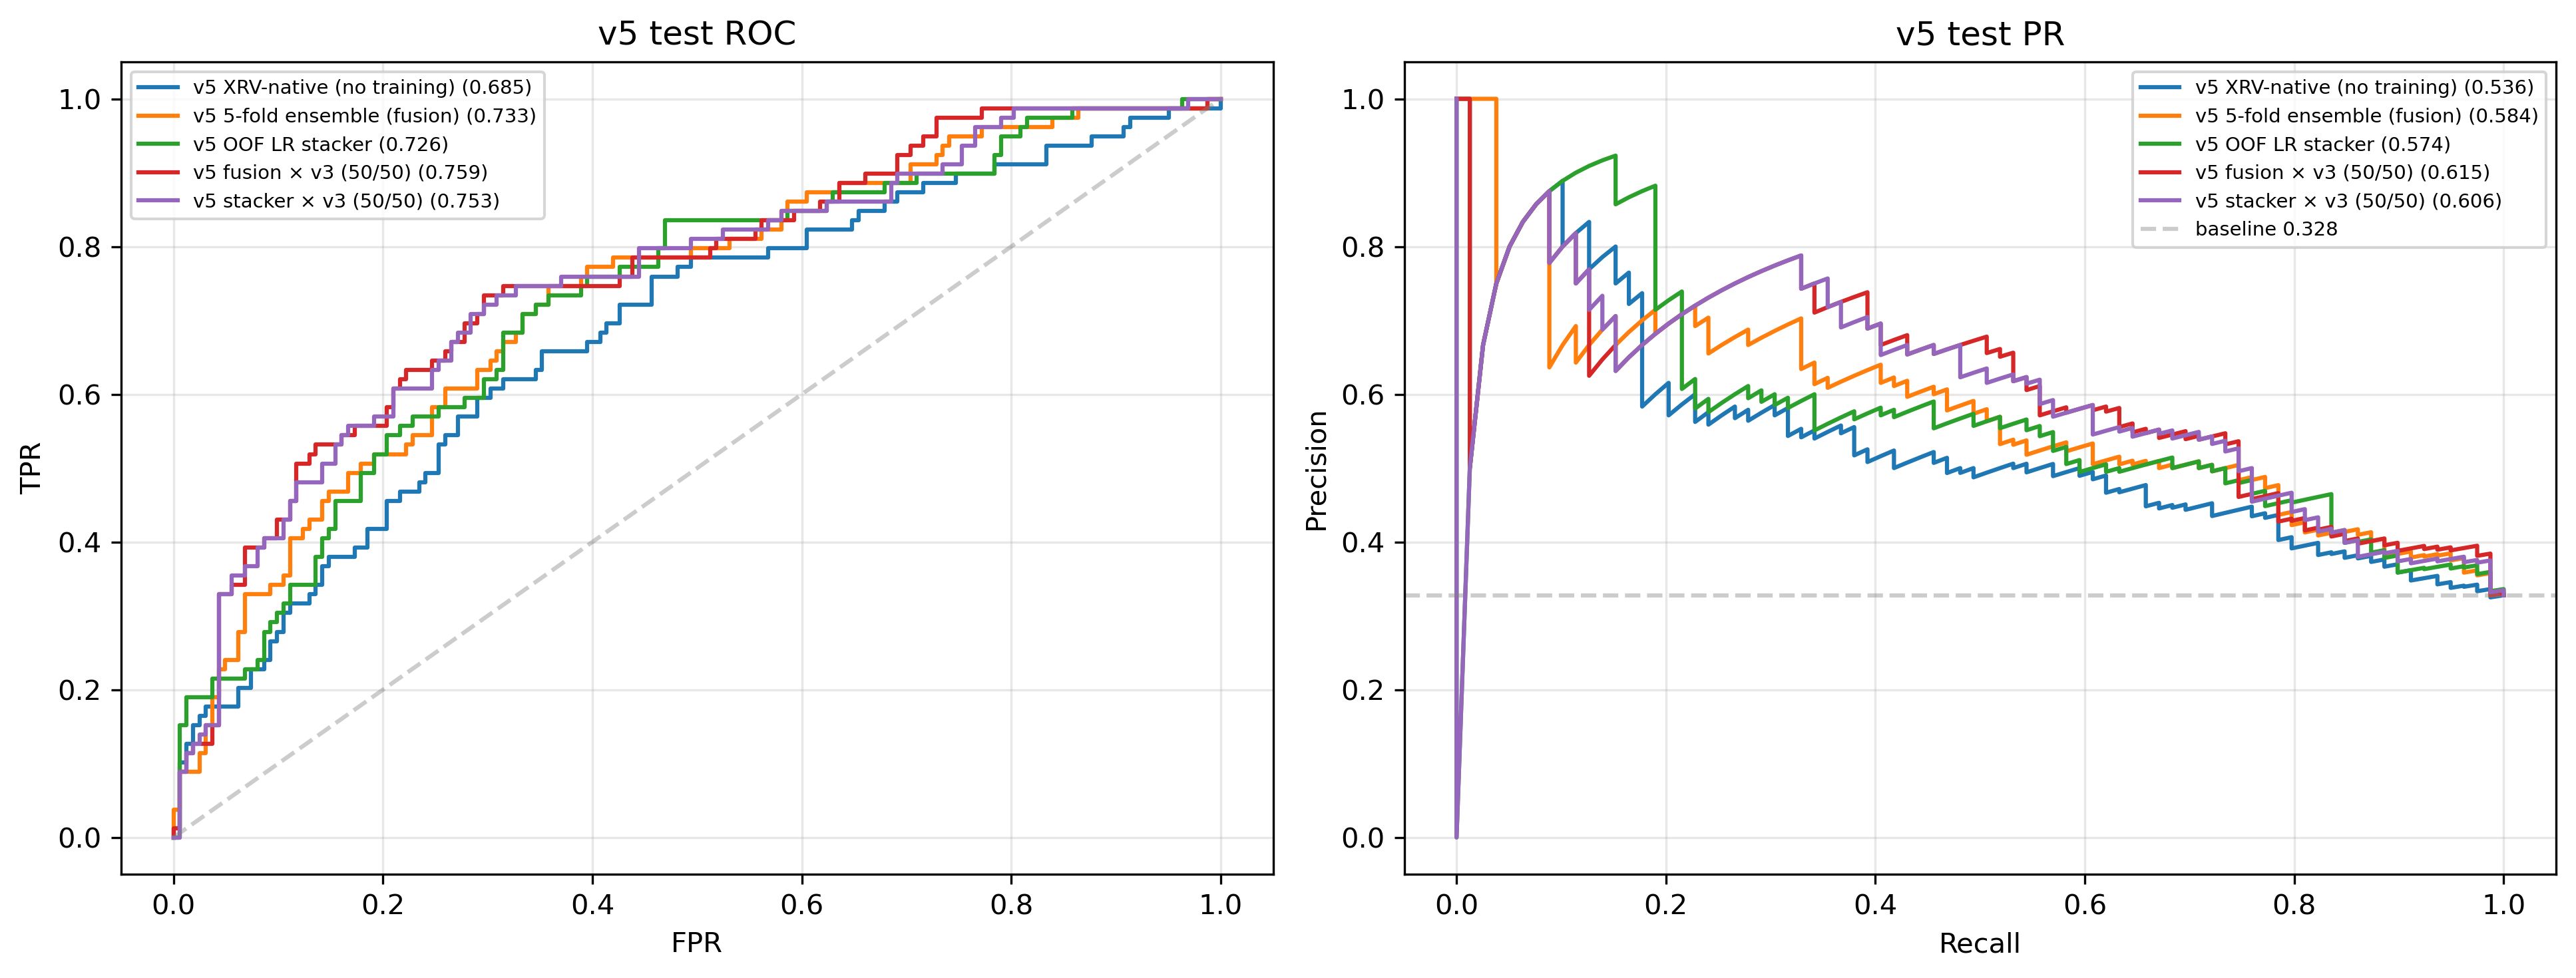

saved: vit_v5_test_predictions.csv + vit_v5_oof.npz


In [13]:
# ---- 5.4 Final leaderboard + ROC / PR plot + save ----
board = {
    'v5 XRV-native (no training)': test_xrv_pneu_ens,
    'v5 5-fold ensemble (fusion)': test_ens,
    'v5 OOF LR stacker':           p_stack_te,
}
if 'p_cross' in globals() and p_cross is not None:
    board['v5 fusion × v3 (50/50)']  = p_cross
if 'p_cross2' in globals() and p_cross2 is not None:
    board['v5 stacker × v3 (50/50)'] = p_cross2

print(f'{"strategy":<32s}  test AUROC   test AUPRC')
print('-' * 62)
best_name, best_auroc, best_probs = None, -1, None
for name, probs in board.items():
    a = roc_auc_score(y_test, probs)
    p = average_precision_score(y_test, probs)
    print(f'{name:<32s}  {a:.4f}       {p:.4f}')
    if a > best_auroc:
        best_auroc = a; best_name = name; best_probs = probs

print('=' * 62)
print(f'BEST on test: {best_name}   AUROC={best_auroc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=300)
for name, probs in board.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    a = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, lw=1.5, label=f'{name} ({a:.3f})')
axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('v5 test ROC')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

for name, probs in board.items():
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, lw=1.5, label=f'{name} ({ap:.3f})')
axes[1].axhline(float(y_test.mean()), linestyle='--', color='gray', alpha=0.4, label=f'baseline {y_test.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('v5 test PR')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

plt.tight_layout()
_plot = RESULTS_DIR / 'v5_xrv_test.png'
plt.savefig(_plot, dpi=300, bbox_inches='tight')
print(f'saved: {_plot}')
plt.show()

# Save predictions + stacker
out = test_df[['subject_id','stay_id','study_id','dicom_id',LABEL_COL]].copy().rename(columns={LABEL_COL:'y_true'})
out['p_xrv_native']      = test_xrv_pneu_ens
out['p_v5_fusion_5fold'] = test_ens
out['p_v5_stacker']      = p_stack_te
if 'p_cross' in globals() and p_cross is not None:
    out['p_v5_fusion_x_v3']  = p_cross
if 'p_cross2' in globals() and p_cross2 is not None:
    out['p_v5_stacker_x_v3'] = p_cross2
for f in range(N_FOLDS):
    out[f'p_v5_fold{f+1}'] = test_fusion[f]
out.to_csv(RESULTS_DIR / 'vit_v5_test_predictions.csv', index=False)
np.savez(RESULTS_DIR / 'vit_v5_oof.npz',
         oof_fusion=oof_fusion, oof_xrv_pneu=oof_xrv_pneu,
         y_tv=y_tv, test_fusion=test_fusion, test_xrv_pneu=test_xrv_pneu,
         per_fold_val_auroc=np.array(per_fold_val_auroc))
print(f'saved: vit_v5_test_predictions.csv + vit_v5_oof.npz')

## 6. Bootstrap 95% confidence interval on the best test AUROC

n_test = 241 is small, so a single point estimate can mislead. A simple stratified bootstrap tells us whether the gap between v5 and v3 is real or within noise.

In [14]:
# ---- 6.1 Bootstrap CI ----
def bootstrap_auroc(y, p, n_boot=2000, seed=0):
    rng = np.random.RandomState(seed)
    n = len(y)
    scores = np.empty(n_boot, dtype=np.float32)
    for i in range(n_boot):
        idx = rng.randint(0, n, size=n)
        yb, pb = y[idx], p[idx]
        if len(np.unique(yb)) < 2:
            scores[i] = np.nan
        else:
            scores[i] = roc_auc_score(yb, pb)
    scores = scores[~np.isnan(scores)]
    return scores.mean(), np.quantile(scores, [0.025, 0.975])

for name, probs in board.items():
    mean_, (lo, hi) = bootstrap_auroc(y_test, probs, n_boot=2000)
    print(f'{name:<32s}  AUROC={mean_:.4f}   95% CI=[{lo:.4f}, {hi:.4f}]   width={hi-lo:.4f}')

v5 XRV-native (no training)       AUROC=0.6844   95% CI=[0.6091, 0.7580]   width=0.1489
v5 5-fold ensemble (fusion)       AUROC=0.7326   95% CI=[0.6639, 0.7969]   width=0.1330
v5 OOF LR stacker                 AUROC=0.7256   95% CI=[0.6547, 0.7927]   width=0.1380
v5 fusion × v3 (50/50)            AUROC=0.7575   95% CI=[0.6907, 0.8221]   width=0.1314
v5 stacker × v3 (50/50)           AUROC=0.7516   95% CI=[0.6825, 0.8168]   width=0.1343


## 7. If v5 still isn't above 0.80

At n_test=241, the AUROC 95% CI width is typically ±0.05, so a point estimate of ~0.78 with a CI spanning [0.73, 0.83] is the realistic statistical ceiling on this dataset size. The remaining moves from here require either more test data or a substantially different architecture:

1. **Grow the test set** — join the held-out 15 % into a larger held-out (maybe 30 %) for a cleaner read; not always possible.
2. **CXR-report text encoder** — encode the radiology report text with ClinicalBERT / GatorTron and fuse it in as a third modality. Often the single biggest jump for pneumonia on MIMIC because the label itself is extracted from the report.
3. **External data pretraining on RSNA Pneumonia** — 30 k labeled images, ~3 GB download. Pretrain v5's fusion head on RSNA, then fine-tune on your cohort.
4. **Vote ensemble across v3 + v5 + SWA + XRV-native** with bayesian model averaging.

Tell me which of these (if any) you want me to build.